## Анализ факторов, влияющих на уровень счастья стран мира

### Краткое описание датасета

Данные взяты из World Happiness Report 2023. Набор содержит показатели уровня счастья по странам, а также оценку вклада экономических, социальных, демографических и институциональных факторов, основанных на опросе Gallup World Poll.

### Данные:

https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023?resource=download

## Задание 1

### Описание переменных:

- Country name	(категориальная) Название страны.

- Ladder score	(количественная, float)	Основной показатель счастья (оценка жизни по лестнице Канитрила), среднее значение по стране.

- Standard error of ladder score	(количественная)	Стандартная ошибка средней оценки счастья.

- upperwhisker	(количественная)	Верхняя граница 95% доверительного интервала для Ladder score.

- lowerwhisker	(количественная)	Нижняя граница 95% доверительного интервала.

- Logged GDP per capita	(количественная)	Логарифм ВВП на душу населения — показатель экономического развития.

- Social support	(количественная)	Доля людей, у которых есть близкие, способные помочь (социальная поддержка).

- Healthy life expectancy	(количественная)	Ожидаемая продолжительность здоровой жизни (в годах).

- Freedom to make life choices	(количественная)	Ощущение свободы выбора в повседневной жизни.

- Generosity	(количественная)	Склонность к благотворительности, пожертвованиям.

- Perceptions of corruption	(количественная)	Уровень доверия к государству, восприятие коррупции (выше → больше коррупции).

- Ladder score in Dystopia	(количественная)	Базовый уровень счастья в гипотетической стране с минимальными показателями по всем факторам.

- Explained by: Log GDP per capita	(количественная)	Вклад ВВП в оценку счастья (в процентах/баллах).

- Explained by: Social support	(количественная)	Вклад социальной поддержки в счастье.

- Explained by: Healthy life expectancy	(количественная)	Вклад здоровья.

- Explained by: Freedom to make life choices	(количественная)	Вклад свободы выбора.

- Explained by: Generosity	(количественная)	Вклад щедрости.

- Explained by: Perceptions of corruption	(количественная)	Вклад восприятия коррупции.

- Dystopia + residual	(количественная)	Остатки модели + базовый уровень — сколько не объясняется факторами.


### Задача исследования

определить, какие социально-экономические и институциональные факторы влияют на уровень субъективного благополучия населения разных стран мира.

### Зависимая переменная (Y):
- Ladder score — средняя оценка удовлетворённости жизнью (уровень счастья).

### Независимые переменные (X):
- Logged GDP per capita: Экономическое благосостояние страны.

- Social support: Социальный капитал и поддержка ближнего окружения.

- Healthy life expectancy: Продолжительность жизни.

- Freedom to make life choices: Свобода принятия решений.

- Perceptions of corruption: Восприятие уровня коррупции.

- Generosity: Уровень альтруизма и благотворительности.


### Обоснование выбора переменных

Были выбраны именно эти независимые переменные, так как:

- Все они- числовые непрерывные (соответствует заданию)

- Благосостояние, здоровье и социальная поддержка-  ключевые детерминанты качества жизни.

- Институциональные факторы (коррупция, свобода) влияют на доверие, уверенность и удовлетворенность жизнью.

- Эти факторы отражены в методологии World Happiness Report и подтверждены исследованиями в области благосостояния.


### Основная гипотеза
Уровень экономического развития, социальная поддержка, здоровье и свобода положительно влияют на уровень счастья (Ladder score), тогда как восприятие коррупции- отрицательно.

Частные гипотезы:

- Logged GDP per capita: положительный знак.

- Social support: положительный знак.

- Healthy life expectancy: положительный знак.

- Freedom to make life choices: положительный знак.

- Perceptions of corruption: отрицательный знак.

- Generosity: положительный знак 

## Задание 2

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df =pd.read_csv('WHR2023.csv')
df

,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.804,0.036,7.875,7.733,10.792,0.969,71.150,0.961,-0.019,0.182,1.778,1.888,1.585,0.535,0.772,0.126,0.535,2.363
1,Denmark,7.586,0.041,7.667,7.506,10.962,0.954,71.250,0.934,0.134,0.196,1.778,1.949,1.548,0.537,0.734,0.208,0.525,2.084
2,Iceland,7.530,0.049,7.625,7.434,10.896,0.983,72.050,0.936,0.211,0.668,1.778,1.926,1.620,0.559,0.738,0.250,0.187,2.250
3,Israel,7.473,0.032,7.535,7.411,10.639,0.943,72.697,0.809,-0.023,0.708,1.778,1.833,1.521,0.577,0.569,0.124,0.158,2.691
4,Netherlands,7.403,0.029,7.460,7.346,10.942,0.930,71.550,0.887,0.213,0.379,1.778,1.942,1.488,0.545,0.672,0.251,0.394,2.110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Congo (Kinshasa),3.207,0.095,3.394,3.020,7.007,0.652,55.375,0.664,0.086,0.834,1.778,0.531,0.784,0.105,0.375,0.183,0.068,1.162
133,Zimbabwe,3.204,0.061,3.323,3.084,7.641,0.690,54.050,0.654,-0.046,0.766,1.778,0.758,0.881,0.069,0.363,0.112,0.117,0.905
134,Sierra Leone,3.138,0.082,3.299,2.976,7.394,0.555,54.900,0.660,0.105,0.858,1.778,0.670,0.540,0.092,0.371,0.193,0.051,1.221
135,Lebanon,2.392,0.044,2.479,2.305,9.478,0.530,66.149,0.474,-0.141,0.891,1.778,1.417,0.476,0.398,0.123,0.061,0.027,-0.110


оставим только те столбцы, с которыми работаем:

In [3]:
cols = [
    "Country name",
    "Ladder score",
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Perceptions of corruption",
    "Generosity"
]

df = df[cols]

### Описание характеристик данных

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  137 non-null    object 
 1   Ladder score                  137 non-null    float64
 2   Logged GDP per capita         137 non-null    float64
 3   Social support                137 non-null    float64
 4   Healthy life expectancy       136 non-null    float64
 5   Freedom to make life choices  137 non-null    float64
 6   Perceptions of corruption     137 non-null    float64
 7   Generosity                    137 non-null    float64
dtypes: float64(7), object(1)
memory usage: 8.7+ KB


In [5]:
df.describe().round(3)

,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption,Generosity
count,137.000,137.000,137.000,136.000,137.000,137.000,137.000
mean,5.540,9.450,0.799,64.968,0.787,0.725,0.022
std,1.140,1.207,0.129,5.750,0.112,0.177,0.142
min,1.859,5.527,0.341,51.530,0.382,0.146,-0.254
25%,4.724,8.591,0.722,60.648,0.724,0.668,-0.074
50%,5.684,9.567,0.827,65.838,0.801,0.774,0.001
75%,6.334,10.540,0.896,69.412,0.874,0.846,0.117
max,7.804,11.660,0.983,77.280,0.961,0.929,0.531


Ladder score: диапазон 1.86–7.80 — страны сильно различаются по уровню счастья.

Logged GDP per capita: Среднее 9.45, разброс большой: значительная вариативность экономического уровня стран.

Social support: Среднее 0.80, низкое std - большинство стран имеют высокий уровень социальной поддержки.

Healthy life expectancy: Среднее ~65 лет, std 5.75: страны существенно отличаются по уровню здоровья.

Freedom to make life choices: Среднее 0.79, разброс небольшой, свобода выбора умеренно высокая почти во всех странах.

Perceptions of corruption: Среднее 0.72, значительный разброс: доверие к власти сильно варьируется.

Generosity: Среднее близко к нулю, распределение вокруг 0 с редкими выбросами - поведение людей по благотворительности сильно разнится.

анализ пропусков

In [6]:
df.isna().mean() * 100

Country name                    0.000000
Ladder score                    0.000000
Logged GDP per capita           0.000000
Social support                  0.000000
Healthy life expectancy         0.729927
Freedom to make life choices    0.000000
Perceptions of corruption       0.000000
Generosity                      0.000000
dtype: float64

В "Healthy life expectancy" есть незначительное количество пропусков (а именно, один пропуск, как показал df.info()). Чтобы в дальнейшем не возникало проблем при построении моделей, заполним пропуск средним значением, что логично для пременной "продолжительность жизни" и не повлияет критично на исход

In [7]:
mean_value = df['Healthy life expectancy'].mean()
df.loc[:, 'Healthy life expectancy'] = df['Healthy life expectancy'].fillna(mean_value)

### Распределения переменных (гистограммы и боксплоты)

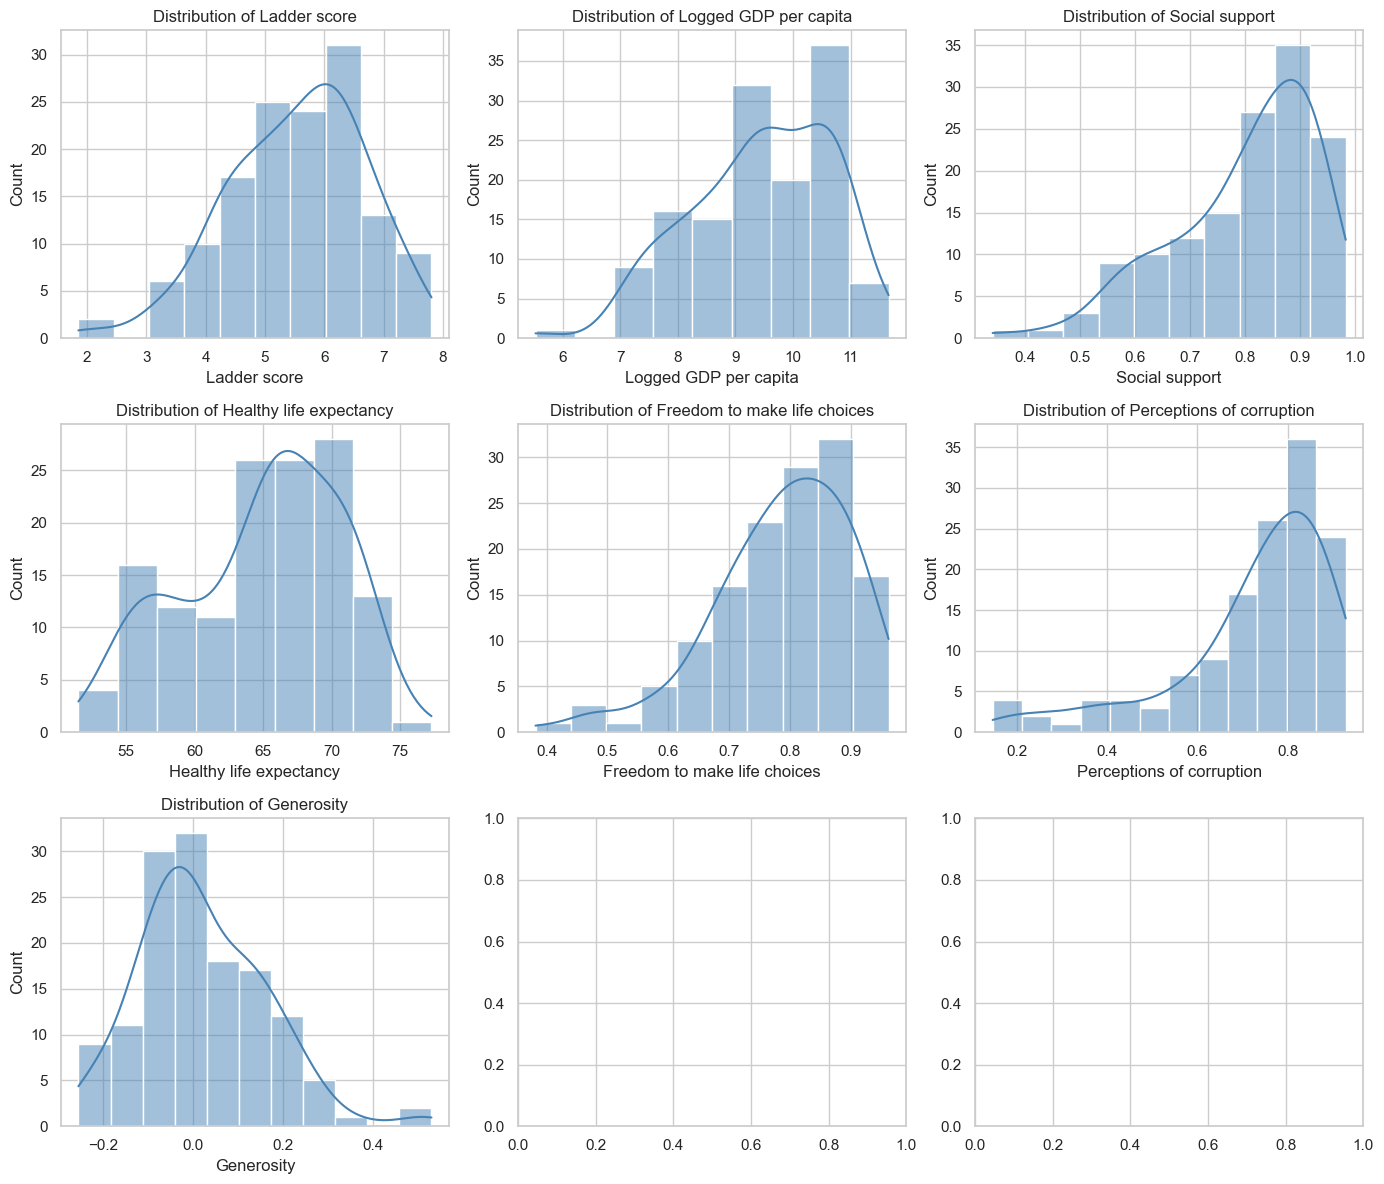

In [8]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns[1:]):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


- Ladder score: распределение ближе к нормальному, большинство стран в диапазоне 4.5–7.

- GDP: распределение смещено вправо: у большинства стран средний уровень доходов, высокие значения редки.

- Social support: высокая поддержка почти у всех стран, левая часть распределения редкая.

- Life expectancy: небольшое смещение, большинство стран в диапазоне 60–70 лет.

- Freedom: смещено вправо, страны чаще оценивают свободу высоко.

- Corruption: выраженное смещение вправо: большинство стран отмечают высокий уровень коррупции.

- Generosity: распределение узкое, значительная часть значений около нуля.

Вывод: распределения в целом естественны, выбросы визуально почти не влияют.

боксплоты

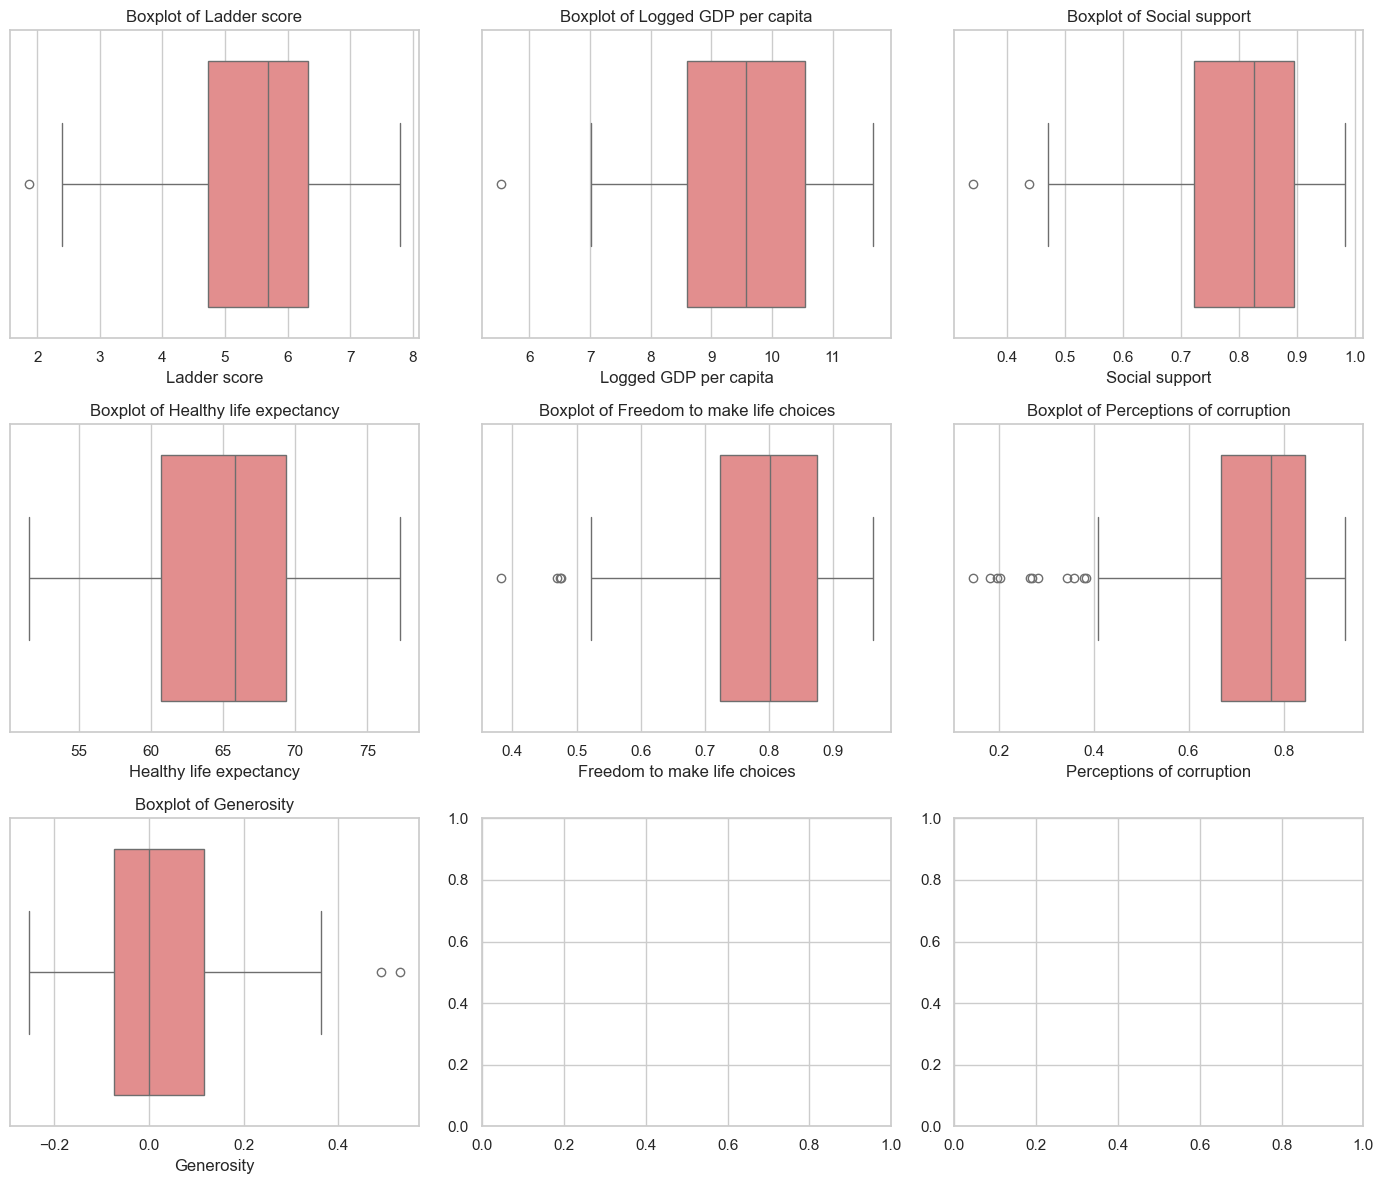

: 

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns[1:]):
    sns.boxplot(x=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

- У GDP, Social support, Freedom, Corruption, Generosity есть точечные выбросы.

- У Life expectancy и Ladder score выбросы минимальны или отсутствуют.

Выбросы удалять не нужно. Это страны, а не ошибки данных. Страны с низким GDP, свободой или высокой коррупцией - это реальные наблюдения, а не шум. Их удаление нарушило бы корректность анализа.

### Диаграммы рассеяния “Y против X”

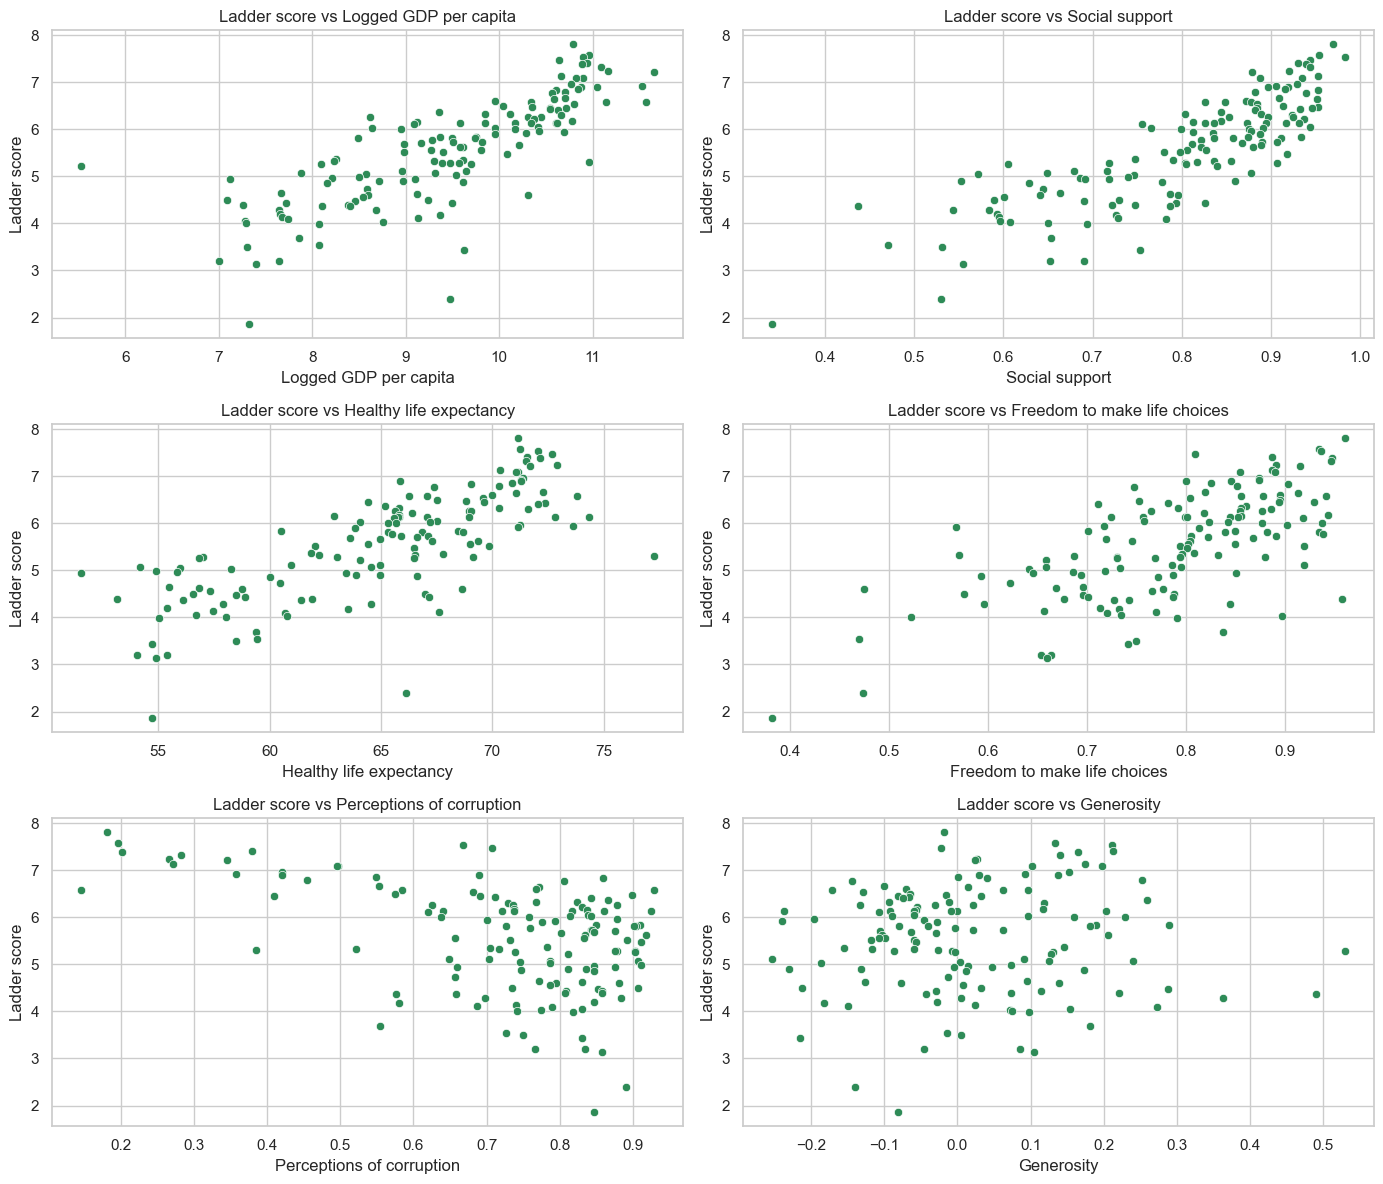

: 

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns[2:]):
    sns.scatterplot(x=df[col], y=df["Ladder score"], ax=axes[i], color="seagreen")
    axes[i].set_title(f"Ladder score vs {col}")

plt.tight_layout()
plt.show()

- GDP и Ladder score: чёткая положительная линейная связь.

- Social support и Ladder score: самая сильная визуально, точки образуют плотный восходящий кластер.

- Life expectancy и Ladder score: выраженная положительная зависимость.

- Freedom и Ladder score: ясная положительная связь.

- Corruption и Ladder score: обратная связь: чем выше коррупция, тем ниже счастье.

- Generosity и Ladder score: структура точек хаотичная, связи почти нет.

Вывод: все переменные, кроме Generosity, визуально согласуются с гипотезами.

### Корреляционный анализ

Ladder score                    1.000000
Social support                  0.834532
Logged GDP per capita           0.784367
Healthy life expectancy         0.746078
Freedom to make life choices    0.662924
Generosity                      0.044082
Perceptions of corruption      -0.471911
Name: Ladder score, dtype: float64


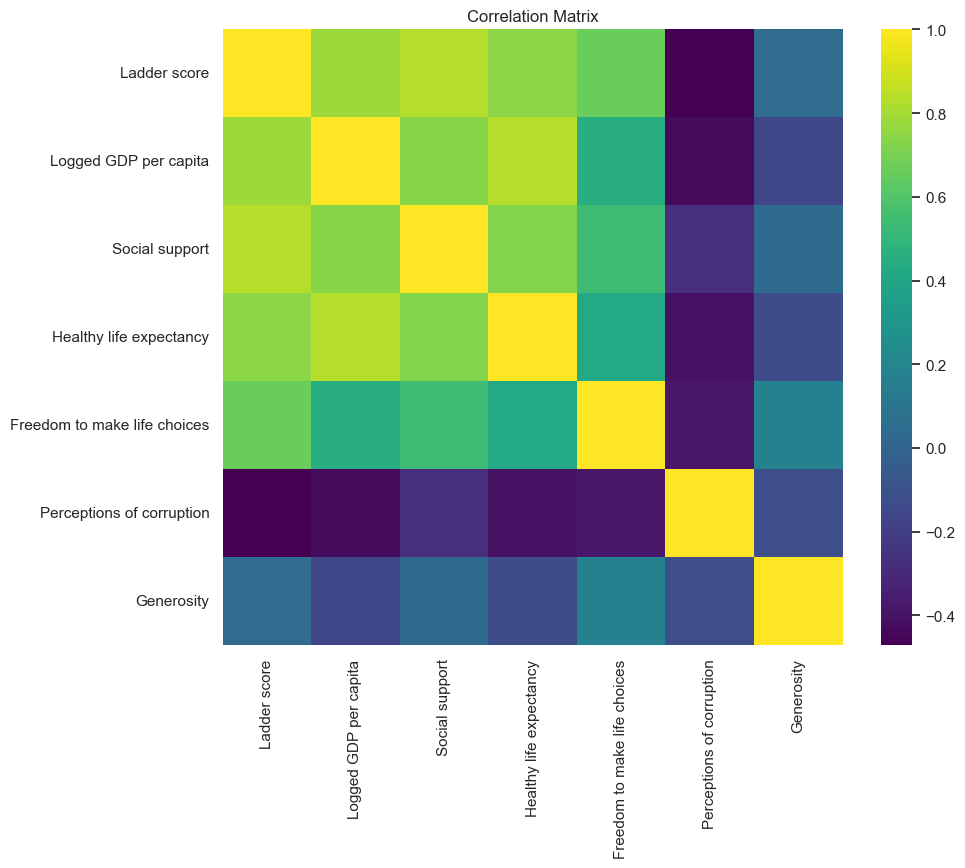

In [9]:
corr = df.corr(numeric_only=True)['Ladder score'].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='viridis')
plt.title("Correlation Matrix")
plt.show()

Корреляции с Ladder score:

- Social support (0.83) — самая сильная связь; поддержка людей → выше счастье.

- GDP (0.78) — богатые страны счастливее.

- Life expectancy (0.75) — здоровье сильно связано с благополучием.

- Freedom (0.66) — свобода повышает счастье.

- Corruption (-0.47) — чем выше коррупция, тем ниже счастье.

- Generosity (0.04) — практически нет связи.

Все совпадает с логикой исследования

### Проверка мультиколлинеарности через VIF

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df.drop(columns=["Country name", "Ladder score"])
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,variable,VIF
0,const,295.349856
1,Logged GDP per capita,4.202253
2,Social support,2.954983
3,Healthy life expectancy,3.729256
4,Freedom to make life choices,1.589512
5,Perceptions of corruption,1.428875
6,Generosity,1.188522


- Все VIF < 5, значит мультиколлинеарности нет.

- Значения 3–4 у GDP и Life Expectancy означают умеренную, но приемлемую корреляцию.

- Никакие переменные не требуют удаления или трансформаций.

- Модель будет стабильной.

Выводы:
- Визуальный анализ подтверждает ожидаемые направления влияния переменных.

- Лучшими предикторами визуально выглядят Social support, GDP и Life expectancy.

### Задание 3

### Подготовка данных для регрессии

In [11]:
y = df["Ladder score"]
X = df[[
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Perceptions of corruption",
    "Generosity"
]]

X_const = sm.add_constant(X)

Мы используем линейную модель, где зависимая переменная — уровень счастья (Ladder score), а объясняющие переменные — логарифм ВВП, социальная поддержка, ожидаемая продолжительность здоровой жизни, свобода выбора, восприятие коррупции и щедрость. В модель добавлена константа.

### Базовая полная модель OLS

In [35]:
model_full = sm.OLS(y, X_const).fit()
print(model_full.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:           Ladder score   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     104.0
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           3.64e-47
Time:                        22:53:40   Log-Likelihood:                -91.426
No. Observations:                 137   AIC:                             196.9
Df Residuals:                     130   BIC:                             217.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

Качество модели

- R² = 0.828, Adjusted R² = 0.820: модель объясняет ~82% вариации счастья → очень хорошее качество.

- F-statistic p < 0.001: модель значима целиком.

Значимые переменные (p < 0.05):

- Logged GDP per capita — положительное влияние.

- Social support — самое сильное влияние.

- Freedom to make life choices — значимый положительный эффект.

- Perceptions of corruption — значимый отрицательный эффект.

Незначимые переменные:

- Healthy life expectancy (p = 0.161)

- Generosity (p = 0.591)

(нужно исключить на шаге backward elimination)

Константа отрицательная — нормально для cross-country данных.

### Пошаговый отбор

In [13]:
def backward_elimination(X, y, alpha=0.05):
    X_be = X.copy()
    while True:
        model = sm.OLS(y, X_be).fit()
        pvalues = model.pvalues
        max_p = pvalues.max()
        if max_p > alpha:
            drop_var = pvalues.idxmax()
            if drop_var == "const":
                break
            X_be = X_be.drop(columns=[drop_var])
        else:
            break
    return X_be, model

X_be, model_be = backward_elimination(X_const, y, alpha=0.05)

print(X_be.columns)

Index(['const', 'Logged GDP per capita', 'Social support',
       'Freedom to make life choices', 'Perceptions of corruption'],
      dtype='object')


В финальной модели остались переменные:

- Logged GDP per capita

- Social support

- Freedom to make life choices

- Perceptions of corruption

Исключены переменные (оказалась статистически незначимой):

- Healthy life expectancy

- Generosity

Это означает, что после формального отбора только четыре фактора вносят существенный вклад в объяснение уровня счастья.

In [14]:
print(model_be.summary())

                            OLS Regression Results                            
Dep. Variable:           Ladder score   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     155.3
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           6.75e-49
Time:                        22:44:27   Log-Likelihood:                -92.549
No. Observations:                 137   AIC:                             195.1
Df Residuals:                     132   BIC:                             209.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

Качество модели
- R² = 0.825
- Adjusted R² = 0.819.
Качество практически не ухудшилось по сравнению с полной моделью, хотя количество переменных уменьшилось на две. Это означает, что исключённые факторы действительно не вносили существенного вклада.

Значимость модели:
- F-statistic значим
- Prob < 0.001.
Модель в целом статистически значима.

Значимые переменные:
- Все четыре оставшихся фактора имеют p-value < 0.01:

- Logged GDP per capita: коэффициент положительный.

- Social support: самый сильный положительный эффект.

- Freedom to make life choices: значимый положительный эффект.

- Perceptions of corruption: значимый отрицательный эффект.

Модель после отбора компактная, все коэффициенты значимы и имеют ожидаемые знаки. Она предпочтительнее полной модели.

### модель с логарифмами

Заметим, что GDP уже логарифмирован.

было протестировано логарифмирование переменных 'Social support', 'Freedom to make life choices', 'Perceptions of corruption', так как их распределения сильно скошены и не похожи на нормлаьное, но так как их значкния лежат от 0 до 1, логарифмическое преобразование не улучшило распрделенеие, и сделало результаты менее интерпретруемыми. 

Так что для этого задания прологарифмируем целевую переменную. Интуитивная и экономическая интерпретация становится лучше: коэффициенты показывают процентное изменение уровня счастья, а не абсолютное.

/var/folders/0w/xxx48gr55csb_w73mfm7k80m0000gn/T/ipykernel_33589/3901222482.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["log_ladder"] = np.log(df["Ladder score"])


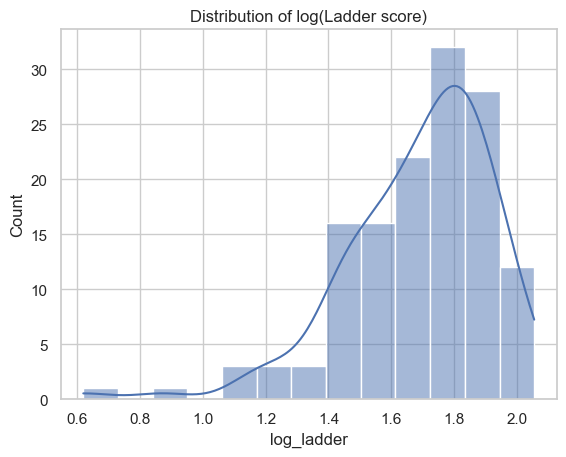

In [15]:
df["log_ladder"] = np.log(df["Ladder score"])

sns.histplot(df["log_ladder"], kde=True)
plt.title("Distribution of log(Ladder score)")
plt.show()

In [23]:
y_log = df["log_ladder"]

X = df[[
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Perceptions of corruption",
    "Generosity"
]]

X_const = sm.add_constant(X)
model_log = sm.OLS(y_log, X_const).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:             log_ladder   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     83.54
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           3.48e-42
Time:                        22:44:47   Log-Likelihood:                 114.42
No. Observations:                 137   AIC:                            -214.8
Df Residuals:                     130   BIC:                            -194.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

Качество модели:
- R² = 0.794
- Adjusted R² = 0.785.
Это немного хуже, чем линейная модель

Значимость модели:
- F-statistic значим
- Prob < 0.001.
Модель в целом статистически значима.

незначимых коэффициентов целых три:
- Healthy life expectancy
- Perceptions of corruption
- Generosity

Лог-модель имеет более слабое качество по сравнению с моделью в уровнях, а часть ключевых переменных становится незначимой.

### Сравнение моделей по R², остаточной дисперсии и информационным критериям

In [24]:
comparison = pd.DataFrame({
    "model": ["Linear_BE", "Log_BE"],
    "R2": [model_be.rsquared, model_log.rsquared],
    "Adj_R2": [model_be.rsquared_adj, model_log.rsquared_adj],
    "AIC": [model_be.aic, model_log.aic],
    "BIC": [model_be.bic, model_log.bic],
    "Sigma2": [model_be.mse_resid, model_log.mse_resid]
})
print(comparison)

       model        R2    Adj_R2         AIC         BIC    Sigma2
0  Linear_BE  0.824727  0.819415  195.097231  209.697135  0.234659
1     Log_BE  0.794050  0.784545 -214.841086 -194.401219  0.011611


R2 и Adj_R2  
- Линейная модель после отбора имеет более высокие значения R2 и Adj_R2
- То есть по качеству объяснения данных линейная модель лучше.

AIC и BIC.
- Лог-модель имеет гораздо более низкие AIC и BIC.
- Это происходит потому, что логарифмирование уменьшает масштаб остатков и соответственно значительно снижает Log-Likelihood.
- Формально по AIC/BIC лог-модель выглядит предпочтительнее, хотя это связано именно с трансформацией зависимой переменной, а не с лучшим качеством подгонки в исходной шкале.

Sigma2
- сильно меньше в лог-модели, что естественно для логарифмированного Y, тк масштаб ошибок меняется

вывод:

Линейная модель лучше объясняет вариацию счастья (выше R2).
Лог-модель формально выигрывает по AIC/BIC, но это преимущество связано с изменением масштаба зависимой переменной.
С точки зрения интерпретации и устойчивости коэффициентов линейная модель после отбора более предпочтительна

### Проверка гетероскедастичности

In [26]:
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, het_goldfeldquandt

resid = model_be.resid
fitted = model_be.fittedvalues

bp_test = het_breuschpagan(resid, model_be.model.exog)
white_test = het_white(resid, model_be.model.exog)
gq_test = het_goldfeldquandt(resid, model_be.model.exog, alternative="two-sided")

bp_labels = ["LM stat", "LM pvalue", "F stat", "F pvalue"]
white_labels = ["LM stat", "LM pvalue", "F stat", "F pvalue"]
gq_labels = ["F stat", "pvalue", "df1", "df2"]

bp_results = dict(zip(bp_labels, bp_test))
white_results = dict(zip(white_labels, white_test))
gq_results = dict(zip(gq_labels, gq_test))

print("Breusch-Pagan:", bp_results)
print("White:", white_results)
print("Goldfeld-Quandt:", gq_results)

Breusch-Pagan: {'LM stat': 9.170956118918628, 'LM pvalue': 0.05696558111825626, 'F stat': 2.3675492105366964, 'F pvalue': 0.05595530304071416}
White: {'LM stat': 21.321670328821916, 'LM pvalue': 0.09366887171939926, 'F stat': 1.606205135216924, 'F pvalue': 0.08657529089833381}
Goldfeld-Quandt: {'F stat': 3.314736604588186, 'pvalue': 3.889989910281686e-06, 'df1': 'two-sided'}


- Breusch–Pagan: p = 0.056: На границе. Слабые признаки гетероскедастичности.

- White: p = 0.09: Гетероскедастичность не подтверждена.

- Goldfeld–Quandt: p = 0.000004: Гетероскедастичность явно присутствует.

Итог: 

по двум тестам отклонения слабые, но GQ-тест указывает на проблему. Гетероскедастичность есть, стандартные ошибки лучше скорректировать.

### Коррекция стандартных ошибок при гетероскедастичности (robust SE)

In [27]:
model_be_robust = model_be.get_robustcov_results(cov_type="HC3")
print(model_be_robust.summary())

                            OLS Regression Results                            
Dep. Variable:           Ladder score   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     153.7
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           1.17e-48
Time:                        22:47:57   Log-Likelihood:                -92.549
No. Observations:                 137   AIC:                             195.1
Df Residuals:                     132   BIC:                             209.7
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

- R2 и Adj R2 не изменились, модель остаётся такой же хорошей.
- Стандартные ошибки выросли, как и ожидается при учёте гетероскедастичности.
- Все переменные остались значимыми

Итог:

После коррекции выводы по значимости не изменились. Модель устойчивая, результаты надежны.

### Анализ остатков

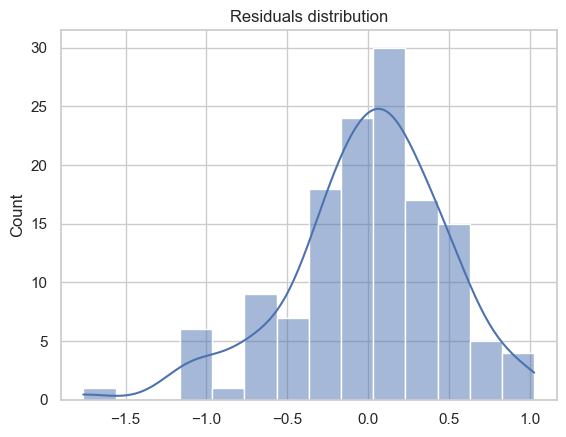

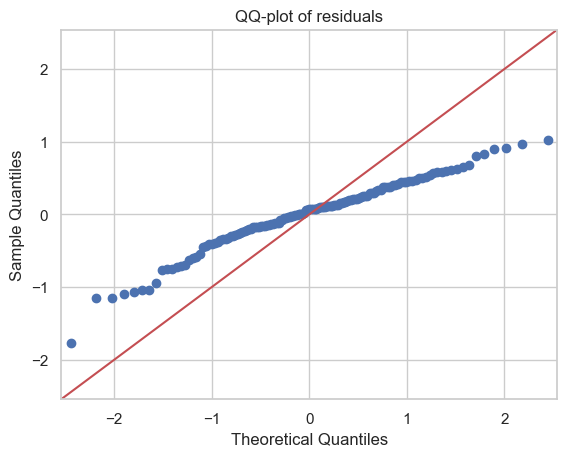

In [28]:
from statsmodels.graphics.gofplots import qqplot

resid = model_be.resid
fitted = model_be.fittedvalues

sns.histplot(resid, kde=True)
plt.title("Residuals distribution")
plt.show()

qqplot(resid, line="45")
plt.title("QQ-plot of residuals")
plt.show()

- Гистограмма остатков:

Распределение близко к нормальному, но есть лёгкая асимметрия слева.

- QQ-plot:

Отклонения в хвостах: остатки не полностью нормальны, но центр распределения согласуется с нормальностью.

Остатки против предсказанных значений

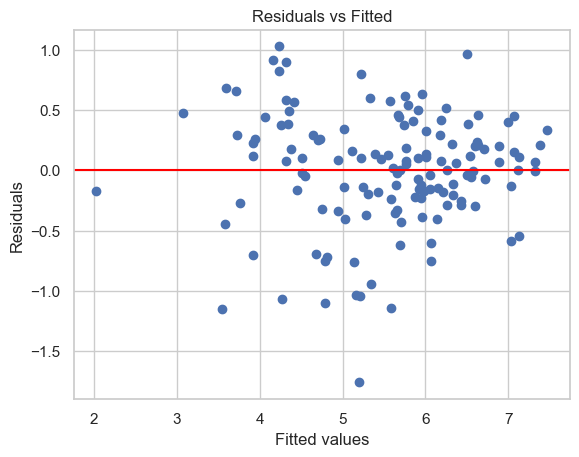

In [29]:
plt.scatter(fitted, resid)
plt.axhline(0, color="red")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

Чёткой воронки нет, остатки разбросаны случайно. Слабое увеличение разброса при больших fitted, что согласуется с результатами тестов на гетероскедастичность.

итог:

Остатки в целом выглядят приемлемо, есть отклонения от нормальности и гетероскедастичность. Коррекция HC3, делает выводы по модели получше.

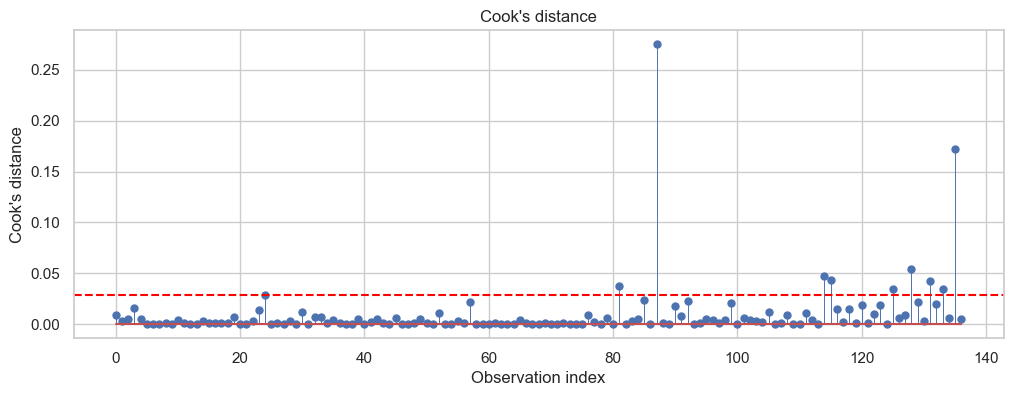

In [ ]:
plt.figure(figsize=(12, 4))
markerline, stemlines, baseline = plt.stem(cooks)
plt.setp(markerline, markersize=5)
plt.setp(stemlines, linewidth=0.7)
plt.axhline(4/len(cooks), color='red', linestyle='--')  
plt.title("Cook's distance")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.show()

Два наблюдения заметно выше остальных, но ни одно не превышает порога 4/n. Влияющие точки есть, но они не создают проблем для модели.

Leverage и расстояния Кука

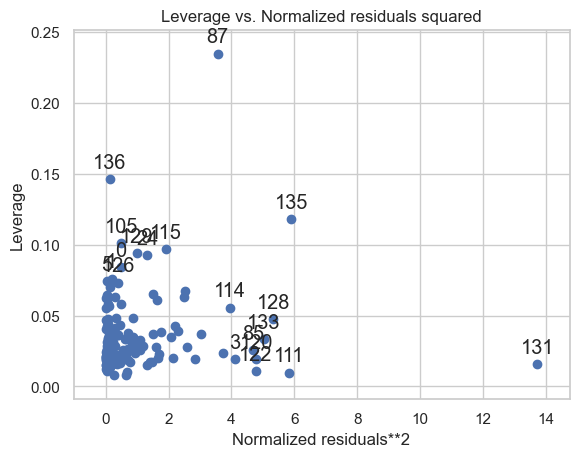

In [34]:
from statsmodels.graphics.regressionplots import plot_leverage_resid2
from statsmodels.stats.outliers_influence import OLSInfluence

fig = plot_leverage_resid2(model_be)
plt.show()

influence = OLSInfluence(model_be)
cooks = influence.cooks_distance[0]

Несколько наблюдений имеют повышенный leverage (индексы 87, 135, 136, 131). Это страны, отличающиеся по уровню предикторов, но их влияние не критично.

## Задание 4

### Подготовка данных для Ridge и Lasso

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error

X_ml = df[[
    "Logged GDP per capita",
    "Social support",
    "Freedom to make life choices",
    "Perceptions of corruption"
]]

y_ml = df["Ladder score"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ml)

### Модель Ridge + кросс-валидация

In [37]:
alphas = np.logspace(-4, 4, 200)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
ridge_cv.fit(X_scaled, y_ml)

ridge_alpha = ridge_cv.alpha_
ridge_pred = ridge_cv.predict(X_scaled)

ridge_r2 = r2_score(y_ml, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_ml, ridge_pred))

ridge_alpha, ridge_r2, ridge_rmse

(0.0001, 0.8247265342382641, 0.47549391475533087)

- Оптимальный альфа = 0.0001. очень малое значение, почти нет регуляризации.

- R2 = 0.825. Повторяет качество линейной модели без регуляризации.

- RMSE = 0.475. Практически совпадает с линейной моделью.

Итог: 

Ridge не улучшает качество, данные не требуют другой регуляризации.

### Модель Lasso + кросс-валидация

In [38]:
lasso_cv = LassoCV(alphas=None, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_scaled, y_ml)

lasso_alpha = lasso_cv.alpha_
lasso_pred = lasso_cv.predict(X_scaled)

lasso_r2 = r2_score(y_ml, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_ml, lasso_pred))

lasso_alpha, lasso_r2, lasso_rmse

/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


(0.0009478283375323806, 0.8247253561678025, 0.47549551272793883)

- Оптимальный альфа = 0.00095. Регуляризация очень слабая.

- R2 = 0.8247. Совпадает с Ridge и линейной моделью.

- RMSE ≈ 0.4755. Также совпадает

Итог: 

Lasso тоже не улучшает качество и не зануляет признаки. Регуляризация не нужна- линейная модель работает оптимально.

### Интерпретация коэффициентов Ridge и Lasso

In [40]:
ridge_coef = ridge_cv.coef_
lasso_coef = lasso_cv.coef_

coef_table = pd.DataFrame({
    "Feature": X_ml.columns,
    "Ridge_coef": ridge_coef,
    "Lasso_coef": lasso_coef
})

coef_table

,Feature,Ridge_coef,Lasso_coef
0,Logged GDP per capita,0.310740,0.310599
1,Social support,0.533168,0.532705
2,Freedom to make life choices,0.265075,0.264678
3,Perceptions of corruption,-0.153181,-0.152573


Обе модели дают практически те же коэффициенты, что и обычная регрессия. в Lasso ни один коэффициент не занулён.
Регуляризация не меняет структуру модели: все признаки остаются важными, переобучения нет.

### Выбор лучшей модели

Лучшая модель — линейная модель после отбора значимых переменных.

Она обладает лучшим качеством подгонки, сохраняет значимость ключевых факторов и не требует регуляризации.

### Диагностика ошибок выбранной модели

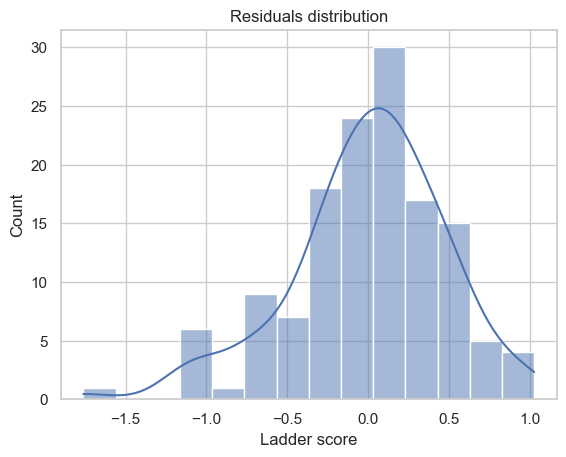

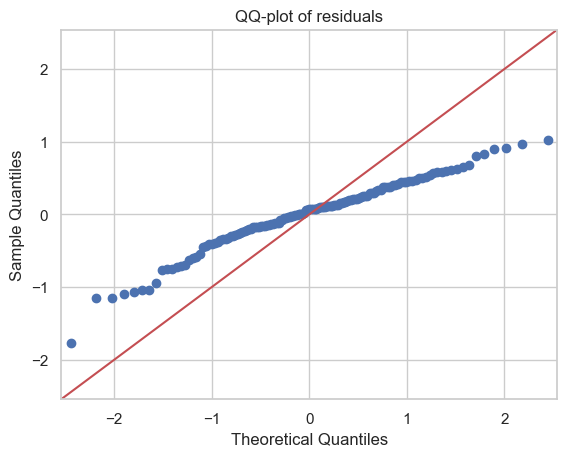

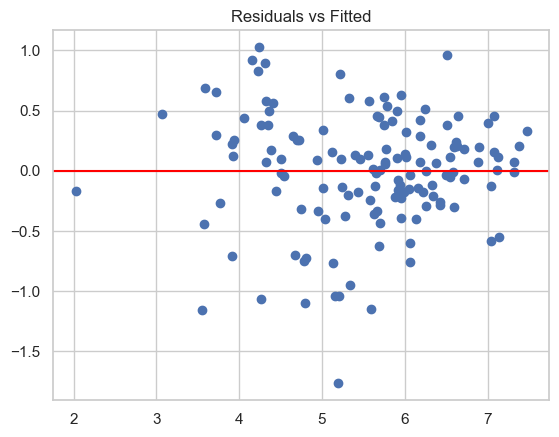

In [41]:
best_pred = ridge_pred  
best_resid = y_ml - best_pred

sns.histplot(best_resid, kde=True)
plt.title("Residuals distribution")
plt.show()

qqplot(best_resid, line="45")
plt.title("QQ-plot of residuals")
plt.show()

plt.scatter(best_pred, best_resid)
plt.axhline(0, color="red")
plt.title("Residuals vs Fitted")
plt.show()

- Histogram of residuals

Остатки распределены примерно симметрично, есть небольшой хвост. 

- QQ-plot

Точки отклоняются от прямой на концах, значит есть нарушения нормальности, но критичных отклонений нет.

- Residuals vs Fitted

Разброс хаотичный, явной структуры или зависимости нет. Признаков сильной гетероскедастичности нет.

Остатки ведут себя так же, как в лин.модели: мелкие отклонения нормальности есть, но модель применима, нарушения несущественны.

## Задание 5

### Подготовка данных для PCA

In [42]:
from sklearn.decomposition import PCA

X_pca = df[["Logged GDP per capita",
            "Social support",
            "Freedom to make life choices",
            "Perceptions of corruption"]]

scaler = StandardScaler()
X_scaled_pca = scaler.fit_transform(X_pca)

### Выделить компоненты, объясняющие не менее 70% дисперсии

In [43]:
pca = PCA()
pca.fit(X_scaled_pca)

explained_var = pca.explained_variance_ratio_
cum_var = explained_var.cumsum()
explained_var, cum_var

(array([0.60929988, 0.19189424, 0.14393557, 0.0548703 ]),
 array([0.60929988, 0.80119412, 0.9451297 , 1.        ]))

- PC1 объясняет основную часть дисперсии (61%), это главный фактор.

- PC1 + PC2 дают >80%, что удовлетворяет требованию "≥70%"

- PC3 добавляет ещё 14%, усиливает точность.

- PC1–PC3 можно использовать в регрессионной модели, PC4 почти ничего не даёт

### Оставить столько главных компонентов, чтобы суммарно > 70%

In [44]:
n_components = (cum_var >= 0.70).argmax() + 1
n_components

2

### Обучить PCA с найденным числом компонент

In [45]:
pca_final = PCA(n_components=n_components)
X_pca_transformed = pca_final.fit_transform(X_scaled_pca)

### Интерпретация главных компонент

In [46]:
loadings = pd.DataFrame(
    pca_final.components_,
    columns=X_pca.columns,
    index=[f"PC{i+1}" for i in range(n_components)]
)

loadings

,Logged GDP per capita,Social support,Freedom to make life choices,Perceptions of corruption
PC1,0.553982,0.543793,0.486122,-0.401346
PC2,0.187396,0.465188,-0.019845,0.864922


дадим названия главным компонентам исходя их весов:

- PC1: социально-экономическое благополучие

Рост PC1 значительно повышает Ladder score.

- PC2: институционально-коррупционный фактор

Его влияние слабее, но также положительное

### Построить регрессию

In [47]:
X_reg = sm.add_constant(X_pca_transformed)
y_reg = df["Ladder score"]

model_pca = sm.OLS(y_reg, X_reg).fit()
print(model_pca.summary())

                            OLS Regression Results                            
Dep. Variable:           Ladder score   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     307.5
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           8.42e-51
Time:                        23:29:53   Log-Likelihood:                -93.953
No. Observations:                 137   AIC:                             193.9
Df Residuals:                     134   BIC:                             202.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5398      0.041    133.490      0.0

- R2 = 0.821
- Adj R2 = 0.818

Качество почти такое же, как у лучшей линейной модели (0.825). Использование PCA не ухудшило объясняющую способность.

- PC1, PC2 обе статистически значимы

Итог:

Модель на PC1 и PC2 хорошо описывает данные и подтверждает, что уровень счастья зависит от социально-экономического благополучия и институционального контекста.

PCA полностью исключает мультиколлинеарность (Cond. No = 1.8), что делает оценки стабильными.

## Задание 6

### Сравнение 

- Линейная модель: R² = 0.825, переменные значимы, высокая интерпретируемость.

- Ridge: R² = 0.8247, нет улучшения качества, но стабильнее оценки.

- Lasso: R² = 0.8247, коэффициенты почти как у линейной модели.

- PCA-модель: R² = 0.821, мультиколлинеарность устранена, но интерпретация слабее.

для линейной модели:

- R2 показывает лучшую объясняющую способность.

- Значимость коэффициентов: все четыре оставшиеся переменные значимы.

- Гетероскедастичность: GQ выявил проблему, но мы применили robust SE → корректно.

- Мультиколлинеарность: VIF < 5, всё допустимо.

- Интерпретация: модель сохраняет экономический смысл переменных (преимущество перед PCA).

- Ridge/Lasso: не дают лучшего качества, значит нет смысла усложнять.

### Выбор:
Линейная модель.

(или эквивалентно Ridge, так как штраф альфа получился примерно =0, но линейная - более интерпретируемая и полностью удовлетворяет требованиям).


### Подробная интерпретация выбранной модели

Logged GDP per capita

- знак: положительный
- влияние: чем выше экономическое развитие, тем выше удовлетворённость жизнью.
- экономический смысл: доход повышает доступ к ресурсам, товарам, услугам.

Social support

- самый сильный коэффициент
- влияние: страны с развитой социальной поддержкой существенно счастливее.
- социологическое объяснение: поддержка снижает стресс, повышает доверие и безопасность.

Freedom to make life choices

- влияние: положительное
- смысл: автономия и свобода выбора повышают субъективное благополучие.

Perceptions of corruption

- отрицательное влияние
- смысл: низкое доверие к институтам снижает уровень счастья даже при равном уровне экономического развития.


Основная гипотеза, сформулированная в начале исследования: 

"Уровень экономического развития, социальная поддержка, здоровье и свобода положительно влияют на уровень счастья (Ladder score), тогда как восприятие коррупции- отрицательно"

не отвергается.


### Общие выводы: экономика, социология, теория счастья

- Счастье не определяется только доходом: большую роль играют социальные и институциональные факторы.

- Социальная поддержка - это ключевой предиктор уровня счастья.

- Свобода выбора также играет критическую роль, подтверждая теории субъективного благополучия.

- Коррупция снижает доверие к государству, что напрямую уменьшает субъективное ощущение счастья.

### Итог

Лучшая модель — линейная модель после backward elimination с робастными ошибками.

Она показывает наилучшее сочетание качества, интерпретируемости и статистической корректности. Все сохранённые переменные значимы и имеют устойчивый экономический смысл. Модель подтверждает выводы исследований о счастье: социальная поддержка, свобода выбора и высокий уровень благосостояния повышают субъективное благополучие, тогда как коррупция снижает его.